In [24]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Increase display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Suppress warnings (optional)
import warnings
warnings.filterwarnings('ignore')

In [42]:
# STEP 2: Define dataset columns (from NSL-KDD dataset)
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'outcome','level'
]

# STEP 3: Load Train & Test data
train = pd.read_csv(r"D:\SpringBoard\SentinelNet\Dataset\KDDTrain+.txt", names=columns)
test  = pd.read_csv(r"D:\SpringBoard\SentinelNet\Dataset\KDDTest+.txt", names=columns)
print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (125973, 43)
Test shape: (22544, 43)


In [43]:
# STEP 4: Map attacks into categories
dos = ['back','land','neptune','pod','smurf','teardrop']
probe = ['satan','ipsweep','nmap','portsweep']
r2l = ['guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy']
u2r = ['buffer_overflow','loadmodule','perl','rootkit']

def map_attack_category(label):
    if label == "normal":
        return "normal"
    elif label in dos:
        return "dos"
    elif label in probe:
        return "probe"
    elif label in r2l:
        return "r2l"
    elif label in u2r:
        return "u2r"
    else:
        return "unknown"

train["attack_category"] = train["outcome"].apply(map_attack_category)
test["attack_category"]  = test["outcome"].apply(map_attack_category)
print(train["attack_category"])
print(test["attack_category"])

0         normal
1         normal
2            dos
3         normal
4         normal
           ...  
125968       dos
125969    normal
125970    normal
125971       dos
125972    normal
Name: attack_category, Length: 125973, dtype: object
0            dos
1            dos
2         normal
3        unknown
4        unknown
          ...   
22539     normal
22540     normal
22541        dos
22542     normal
22543    unknown
Name: attack_category, Length: 22544, dtype: object


In [44]:
print("Attack counts in TRAIN:")
print(train['attack_category'].value_counts())

print("\nAttack counts in TEST:")
print(test['attack_category'].value_counts())


Attack counts in TRAIN:
attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

Attack counts in TEST:
attack_category
normal     9711
dos        5741
unknown    3750
r2l        2199
probe      1106
u2r          37
Name: count, dtype: int64


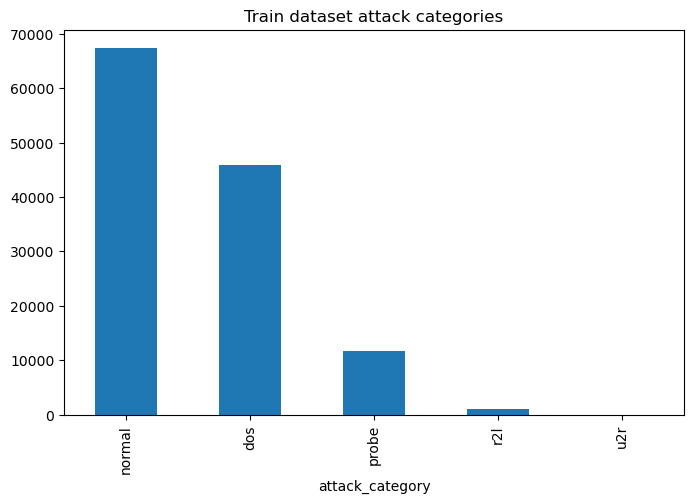

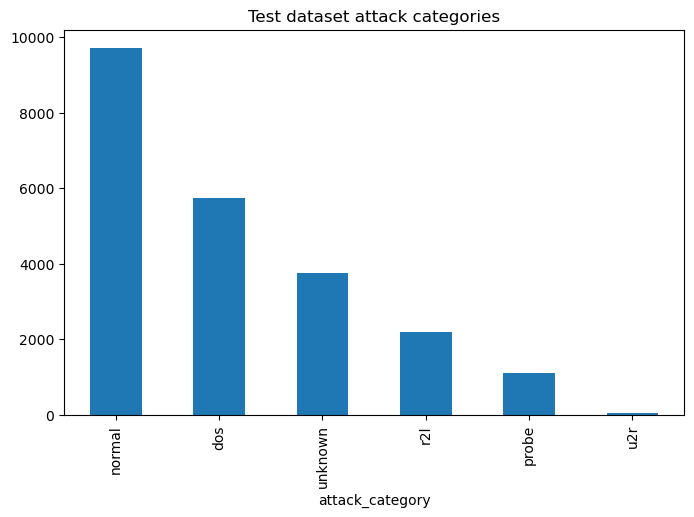

In [45]:
plt.figure(figsize=(8,5))
train['attack_category'].value_counts().plot(kind='bar')
plt.title("Train dataset attack categories")
plt.show()

plt.figure(figsize=(8,5))
test['attack_category'].value_counts().plot(kind='bar')
plt.title("Test dataset attack categories")
plt.show()


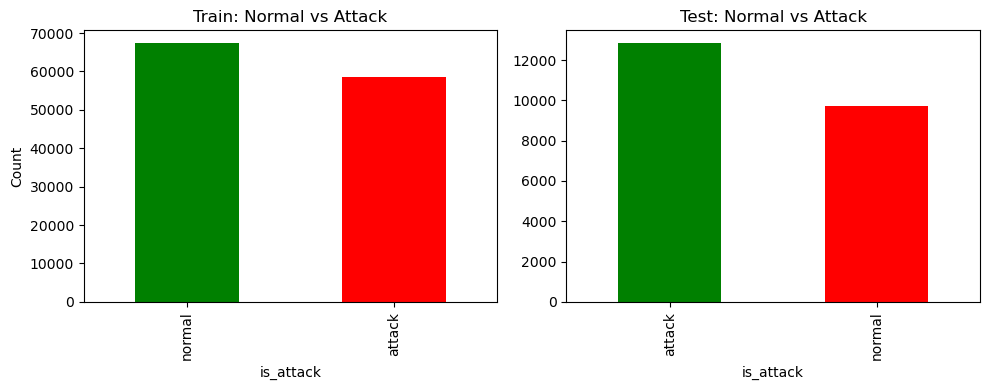

In [49]:

# Create Normal vs Attack column
train['is_attack'] = train['attack_category'].apply(lambda x: 'attack' if x != 'normal' else 'normal')
test['is_attack']  = test['attack_category'].apply(lambda x: 'attack' if x != 'normal' else 'normal')
fig, axes = plt.subplots(1, 2, figsize=(10,4))

train['is_attack'].value_counts().plot(kind='bar', ax=axes[0], color=['green','red'])
axes[0].set_title("Train: Normal vs Attack")
axes[0].set_ylabel("Count")

test['is_attack'].value_counts().plot(kind='bar', ax=axes[1], color=['green','red'])
axes[1].set_title("Test: Normal vs Attack")

plt.tight_layout()
plt.show()
